# Used Car Price Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\abhin\OneDrive\Desktop\Screening Batch\Projects\Used Car Price Prediction\used_cars.csv")
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [4]:
df.isna().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [5]:
df['brand'].unique()

array(['Ford', 'Hyundai', 'Lexus', 'INFINITI', 'Audi', 'Acura', 'BMW',
       'Tesla', 'Land', 'Aston', 'Toyota', 'Lincoln', 'Jaguar',
       'Mercedes-Benz', 'Dodge', 'Nissan', 'Genesis', 'Chevrolet', 'Kia',
       'Jeep', 'Bentley', 'Honda', 'Lucid', 'MINI', 'Porsche', 'Hummer',
       'Chrysler', 'Volvo', 'Cadillac', 'Lamborghini', 'Maserati',
       'Volkswagen', 'Subaru', 'Rivian', 'GMC', 'RAM', 'Alfa', 'Ferrari',
       'Scion', 'Mitsubishi', 'Mazda', 'Saturn', 'Bugatti', 'Polestar',
       'Rolls-Royce', 'McLaren', 'Buick', 'Lotus', 'Pontiac', 'FIAT',
       'Karma', 'Saab', 'Mercury', 'Plymouth', 'smart', 'Maybach',
       'Suzuki'], dtype=object)

In [6]:
df['brand'].value_counts()

brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Mazda             64
Acura             64
Subaru            64
Honda             63
Volkswagen        59
INFINITI          59
Lincoln           52
Jaguar            47
Volvo             38
Maserati          34
Bentley           33
MINI              33
Buick             30
Chrysler          28
Lamborghini       26
Mitsubishi        20
Genesis           20
Alfa              19
Rivian            17
Hummer            16
Pontiac           15
Ferrari           12
Rolls-Royce       11
Aston              9
McLaren            6
Scion              6
FIAT               5
Saturn             5
Lotus              4
Lucid  

In [7]:
df['milage']

0       51,000 mi.
1       34,742 mi.
2       22,372 mi.
3       88,900 mi.
4        9,835 mi.
           ...    
4004       714 mi.
4005    10,900 mi.
4006     2,116 mi.
4007    33,000 mi.
4008    43,000 mi.
Name: milage, Length: 4009, dtype: object

In [8]:
import re
def remove_mi(text):
    pattern="[a-z\.\,]"
    c=re.sub(pattern,"",text)
    return c

<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
C:\Users\abhin\AppData\Local\Temp\ipykernel_11460\3742948451.py:3: SyntaxWarning: invalid escape sequence '\.'
  pattern="[a-z\.\,]"


In [9]:
df['milage']=df['milage'].apply(remove_mi).astype('int64')

In [10]:
df['milage']

0       51000
1       34742
2       22372
3       88900
4        9835
        ...  
4004      714
4005    10900
4006     2116
4007    33000
4008    43000
Name: milage, Length: 4009, dtype: int64

In [11]:
df['fuel_type'].unique()

array(['E85 Flex Fuel', 'Gasoline', 'Hybrid', nan, 'Diesel',
       'Plug-In Hybrid', '–', 'not supported'], dtype=object)

In [12]:
df['fuel_type'].value_counts()

fuel_type
Gasoline          3309
Hybrid             194
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

In [13]:
def convert_fuel(fuel):
    if fuel == 'Plug-In Hybrid':
        return 'Hybrid'
    elif fuel in ['not supported','-','–']:
        return "Other"
    else:
        return fuel

In [14]:
df['fuel_type']=df['fuel_type'].apply(convert_fuel)

In [15]:
df['fuel_type'].isna().sum()

170

In [16]:
df['fuel_type']=df['fuel_type'].replace(np.nan,'Electric')

In [17]:
df

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,10900,Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,2116,Electric,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,33000,Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"


In [18]:
df['engine'].unique()

array(['300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability',
       '3.8L V6 24V GDI DOHC', '3.5 Liter DOHC', ...,
       '136.0HP 1.8L 4 Cylinder Engine Gasoline Fuel',
       '270.0HP 2.0L 4 Cylinder Engine Gasoline Fuel',
       '420.0HP 5.9L 12 Cylinder Engine Gasoline Fuel'], dtype=object)

In [19]:
df['engine'].value_counts()

engine
2.0L I4 16V GDI DOHC Turbo                               52
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel             48
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel             47
–                                                        45
300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel    44
                                                         ..
323.0HP 6.0L 8 Cylinder Engine Gasoline Fuel              1
405.0HP 4.2L 8 Cylinder Engine Gasoline Fuel              1
353.0HP 6.0L 8 Cylinder Engine Gasoline Fuel              1
275.0HP 4.8L 8 Cylinder Engine Gasoline Fuel              1
420.0HP 5.9L 12 Cylinder Engine Gasoline Fuel             1
Name: count, Length: 1146, dtype: int64

In [20]:
df['engine_hp'] = df['engine'].str.extract(r'(\d+\.?\d*)\s?HP', expand=False).astype(float)

In [21]:
df['engine_hp']

0       300.0
1         NaN
2         NaN
3       354.0
4         NaN
        ...  
4004      NaN
4005    349.0
4006      NaN
4007    450.0
4008    248.0
Name: engine_hp, Length: 4009, dtype: float64

In [22]:
df['engine_hp'].isna().sum()

808

Here i first create a liters column, because same liters may be same hp in engine

In [23]:
df['liters'] = df['engine'].str.extract(r'(\d+\.?\d*)\s?L', expand=False).astype(float)

In [24]:
#Fill missing HP based on the median HP for that specific engine size
df['engine_hp'] = df['engine_hp'].fillna(df.groupby('liters')['engine_hp'].transform('median'))

In [25]:
df['engine_hp'].isna().sum()

86

After filling the missing values with the above condition.
If any missing records are there then we can use the median of the engine_hp

In [26]:
df['engine_hp'] = df['engine_hp'].fillna(df['engine_hp'].median())

In [27]:
df['liters']=df['liters'].fillna(df['liters'].median())

In [28]:
df['v_engine']=df['engine'].str.contains(r'V\d+', case=False, na=False)

In [29]:
def enginev(v):
    if v:
        return 1
    else:
        return 0

df['v_engine']=df['v_engine'].apply(enginev)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   object 
 1   model         4009 non-null   object 
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   int64  
 4   fuel_type     4009 non-null   object 
 5   engine        4009 non-null   object 
 6   transmission  4009 non-null   object 
 7   ext_col       4009 non-null   object 
 8   int_col       4009 non-null   object 
 9   accident      3896 non-null   object 
 10  clean_title   3413 non-null   object 
 11  price         4009 non-null   object 
 12  engine_hp     4009 non-null   float64
 13  liters        4009 non-null   float64
 14  v_engine      4009 non-null   int64  
dtypes: float64(2), int64(3), object(10)
memory usage: 469.9+ KB


In [31]:
df['transmission']

0                             6-Speed A/T
1                       8-Speed Automatic
2                               Automatic
3                             7-Speed A/T
4                       8-Speed Automatic
                      ...                
4004    8-Speed Automatic with Auto-Shift
4005       Transmission w/Dual Shift Mode
4006                            Automatic
4007                                  A/T
4008                                  A/T
Name: transmission, Length: 4009, dtype: object

In [32]:
df['transmission'].unique()

array(['6-Speed A/T', '8-Speed Automatic', 'Automatic', '7-Speed A/T',
       'F', 'A/T', '8-Speed A/T', 'Transmission w/Dual Shift Mode',
       '9-Speed Automatic', '6-Speed M/T', '10-Speed A/T', '9-Speed A/T',
       '5-Speed A/T', '1-Speed A/T', 'Automatic CVT',
       '7-Speed Automatic with Auto-Shift', 'CVT-F', 'M/T',
       '6-Speed Automatic with Auto-Shift', '10-Speed Automatic',
       'CVT Transmission', '4-Speed A/T', '6-Speed Automatic',
       '4-Speed Automatic', '7-Speed M/T',
       '8-Speed Automatic with Auto-Shift', '5-Speed Automatic',
       '8-SPEED AT', '1-Speed Automatic', '5-Speed M/T', 'Manual',
       '6-Speed Manual', 'Variable', '2', '7-Speed Manual',
       'Automatic, 9-Spd 9G-Tronic', 'Automatic, 8-Spd',
       'Automatic, 8-Spd Sport w/Sport & Manual Modes', '–',
       'Auto, 6-Spd w/CmdShft', 'Transmission Overdrive Switch',
       '7-Speed Automatic', 'Automatic, 8-Spd PDK Dual-Clutch',
       'Automatic, 8-Spd M STEPTRONIC w/Drivelogic, Sport & Ma

In [33]:
def clean_transmission(text):
    word=str(text).lower()
    manual=['manual','m/t','mt']
    cvt=['cvt','variable']
    single_speed=['single-speed','1-speed','fixed gear']
    auto=['automatic','a/t','at','auto']
    
    if any(m in word for m in manual):
        return "Manual"
    elif any(c in word for c in cvt):
        return "CVT"
    elif any(s in word for s in single_speed):
        return "Single-Speed"
    elif any(a in word for a in auto):
        return "Automatic"
    else:
        return "Other"

In [34]:
df['transmission_type']=df['transmission'].apply(clean_transmission)

In [35]:
df['transmission_type']

0       Automatic
1       Automatic
2       Automatic
3       Automatic
4       Automatic
          ...    
4004    Automatic
4005        Other
4006    Automatic
4007    Automatic
4008    Automatic
Name: transmission_type, Length: 4009, dtype: object

In [36]:
df['ext_col'].unique()

array(['Black', 'Moonlight Cloud', 'Blue', 'Glacier White Metallic',
       'Silver', 'Green', 'Fuji White', 'Yellow', 'White', 'Gray',
       'Purple', 'Iconic Silver Metallic', 'Mythos Black Metallic', 'Red',
       'Gold', 'Lunar Silver Metallic', 'Mountain Air Metallic',
       'Caspian Blue', 'Tango Red Metallic', '–', 'Alpine White',
       'BLU ELEOS', 'Horizon Blue', 'Granite Crystal Clearcoat Metallic',
       'Orange', 'Beige', 'Rift Metallic', 'Atomic Silver',
       'Summit White', 'Imperial Blue Metallic',
       'Magnetic Gray Clearcoat', 'Bright White Clearcoat',
       'Typhoon Gray', 'Crystal Black Silica', 'Arctic Gray Metallic',
       'Selenite Grey Metallic', 'Ultra Black', 'Lunare White Metallic',
       'Hyper Red', 'Daytona Gray Pearl Effect', 'Vik Black',
       'Pacific Blue Metallic', 'Obsidian Black Metallic',
       'Silver Ice Metallic', 'Sonic Silver Metallic', 'Nightfall Mica',
       'Apex Blue', 'Go Mango!', 'Ingot Silver Metallic',
       'Midnight Bl

In [37]:
df['int_col'].unique()

array(['Black', 'Gray', 'Ebony.', 'Green', 'Pimento / Ebony', 'Brown',
       'White', '–', 'Beige', 'Jet Black', 'Light Gray', 'Anthracite',
       'Red', 'Nero Ade', 'Blue', 'Charcoal', 'Rioja Red',
       'Canberra Beige/Black', 'Roast', 'Ivory / Ebony',
       'Silk Beige/Black', 'Medium Pewter', 'Ice', 'Black / Express Red',
       'Obsidian Black', 'Ebony', 'Orange', 'Caramel', 'Orchid',
       'Graphite', 'Tan/Ebony', 'Cappuccino', 'Nero', 'Sahara Tan',
       'BLACK', 'Hotspur', 'Blk', 'Black Onyx', 'Nougat Brown',
       'Titan Black', 'Oyster W/Contrast', 'Silver',
       'Macchiato Beige/Black', 'Sand Beige', 'Navy Pier', 'WHITE',
       'Parchment.', 'Sarder Brown', 'Grace White', 'Cloud', 'Espresso',
       'Mesa', 'Whisper Beige', 'Medium Dark Slate', 'Gold',
       'Camel Leather', 'Tupelo', 'Black/Red', 'Parchment', 'Beluga Hide',
       'Charles Blue', 'Global Black', 'Titan Black / Quarzit', 'Mocha',
       'Portland', 'Medium Light Camel', 'Black / Saddle', 'Ash',
  

In [38]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price', 'engine_hp', 'liters', 'v_engine', 'transmission_type'],
      dtype='object')

In [39]:
df['accident'].unique()

array(['At least 1 accident or damage reported', 'None reported', nan],
      dtype=object)

In [40]:
df['accident']=df['accident'].replace({'At least 1 accident or damage reported':1, 'None reported':0})

C:\Users\abhin\AppData\Local\Temp\ipykernel_11460\1894609001.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['accident']=df['accident'].replace({'At least 1 accident or damage reported':1, 'None reported':0})


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              4009 non-null   object 
 1   model              4009 non-null   object 
 2   model_year         4009 non-null   int64  
 3   milage             4009 non-null   int64  
 4   fuel_type          4009 non-null   object 
 5   engine             4009 non-null   object 
 6   transmission       4009 non-null   object 
 7   ext_col            4009 non-null   object 
 8   int_col            4009 non-null   object 
 9   accident           3896 non-null   float64
 10  clean_title        3413 non-null   object 
 11  price              4009 non-null   object 
 12  engine_hp          4009 non-null   float64
 13  liters             4009 non-null   float64
 14  v_engine           4009 non-null   int64  
 15  transmission_type  4009 non-null   object 
dtypes: float64(3), int64(3),

In [42]:
df['accident']=df['accident'].fillna(0).astype('int64')

In [43]:
df['accident'].isna().sum()

0

In [44]:
df['clean_title'].value_counts()

clean_title
Yes    3413
Name: count, dtype: int64

In [45]:
df['clean_title']=df['clean_title'].replace('Yes',1)

C:\Users\abhin\AppData\Local\Temp\ipykernel_11460\185220089.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['clean_title']=df['clean_title'].replace('Yes',1)


In [46]:
df['clean_title']=df['clean_title'].fillna(0).astype('int64')

In [47]:
df['clean_title']

0       1
1       1
2       0
3       1
4       0
       ..
4004    1
4005    1
4006    0
4007    1
4008    1
Name: clean_title, Length: 4009, dtype: int64

In [48]:
df['price']

0        $10,300
1        $38,005
2        $54,598
3        $15,500
4        $34,999
          ...   
4004    $349,950
4005     $53,900
4006     $90,998
4007     $62,999
4008     $40,000
Name: price, Length: 4009, dtype: object

In [49]:
df['price']=df['price'].replace('[$,]',"",regex=True).astype('int64')

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              4009 non-null   object 
 1   model              4009 non-null   object 
 2   model_year         4009 non-null   int64  
 3   milage             4009 non-null   int64  
 4   fuel_type          4009 non-null   object 
 5   engine             4009 non-null   object 
 6   transmission       4009 non-null   object 
 7   ext_col            4009 non-null   object 
 8   int_col            4009 non-null   object 
 9   accident           4009 non-null   int64  
 10  clean_title        4009 non-null   int64  
 11  price              4009 non-null   int64  
 12  engine_hp          4009 non-null   float64
 13  liters             4009 non-null   float64
 14  v_engine           4009 non-null   int64  
 15  transmission_type  4009 non-null   object 
dtypes: float64(2), int64(6),

In [51]:
df=df.drop(columns=['model','engine','transmission','ext_col','int_col'])

In [52]:
df

,brand,model_year,milage,fuel_type,accident,clean_title,price,engine_hp,liters,v_engine,transmission_type
0,Ford,2013,51000,E85 Flex Fuel,1,1,10300,300.0,3.7,1,Automatic
1,Hyundai,2021,34742,Gasoline,1,1,38005,344.0,3.8,1,Automatic
2,Lexus,2022,22372,Gasoline,0,0,54598,295.0,3.5,0,Automatic
3,INFINITI,2015,88900,Hybrid,0,1,15500,354.0,3.5,1,Automatic
4,Audi,2021,9835,Gasoline,0,0,34999,240.0,2.0,0,Automatic
...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,2023,714,Gasoline,0,1,349950,390.0,6.0,0,Automatic
4005,Audi,2022,10900,Gasoline,0,1,53900,349.0,3.0,1,Other
4006,Porsche,2022,2116,Electric,0,0,90998,308.0,3.5,0,Automatic
4007,Ford,2020,33000,Gasoline,0,1,62999,450.0,3.5,1,Automatic


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              4009 non-null   object 
 1   model_year         4009 non-null   int64  
 2   milage             4009 non-null   int64  
 3   fuel_type          4009 non-null   object 
 4   accident           4009 non-null   int64  
 5   clean_title        4009 non-null   int64  
 6   price              4009 non-null   int64  
 7   engine_hp          4009 non-null   float64
 8   liters             4009 non-null   float64
 9   v_engine           4009 non-null   int64  
 10  transmission_type  4009 non-null   object 
dtypes: float64(2), int64(6), object(3)
memory usage: 344.7+ KB


<Axes: xlabel='brand'>

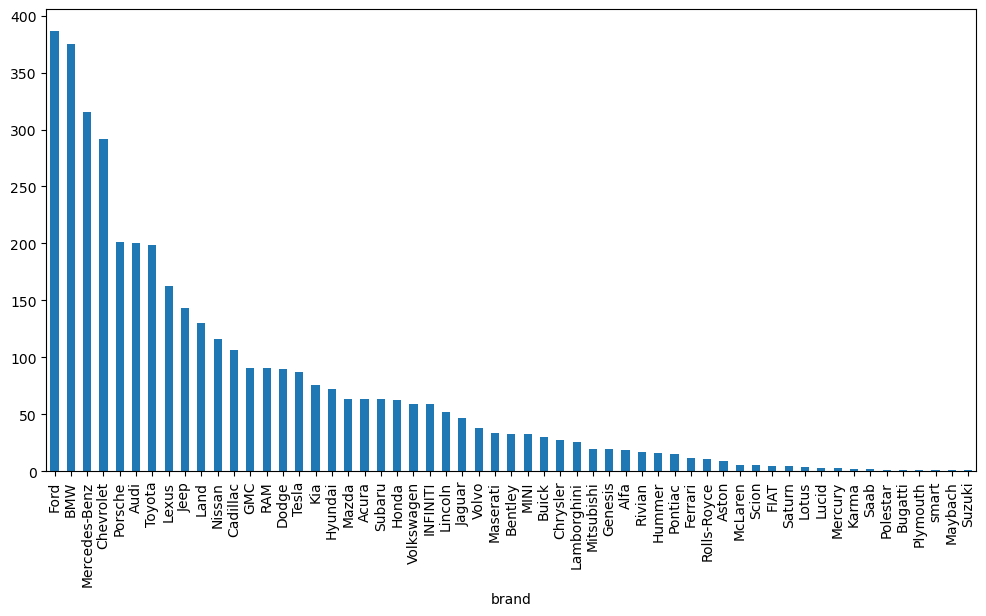

In [54]:
plt.figure(figsize=(12,6))
df['brand'].value_counts().plot(kind='bar')

<Axes: xlabel='brand'>

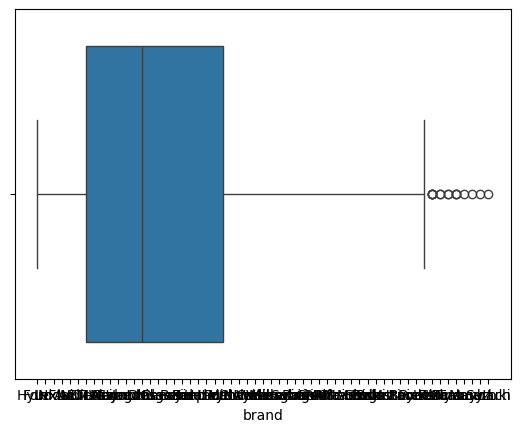

In [55]:
sns.boxplot(x=df['brand'])

<Axes: xlabel='model_year'>

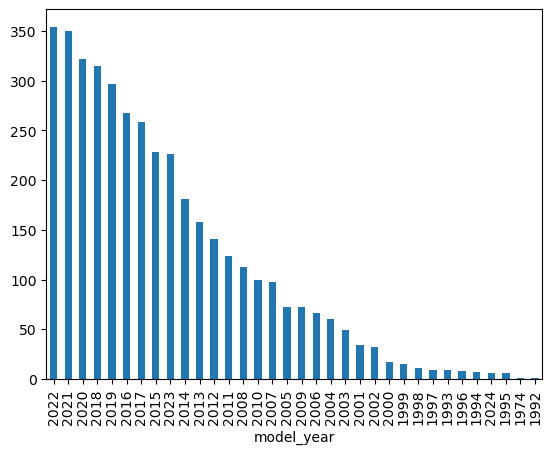

In [56]:
df['model_year'].value_counts().plot(kind='bar')

<Axes: xlabel='model_year'>

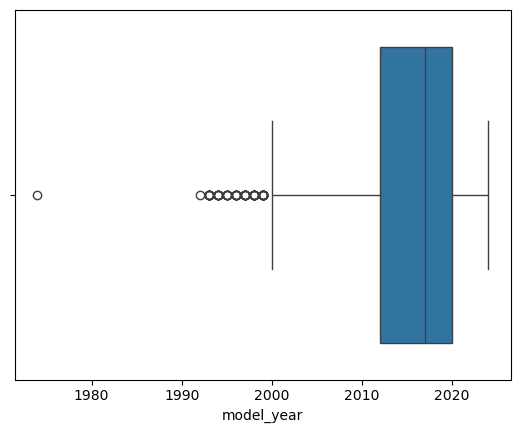

In [57]:
sns.boxplot(x=df['model_year'])

<Axes: xlabel='brand', ylabel='model_year'>

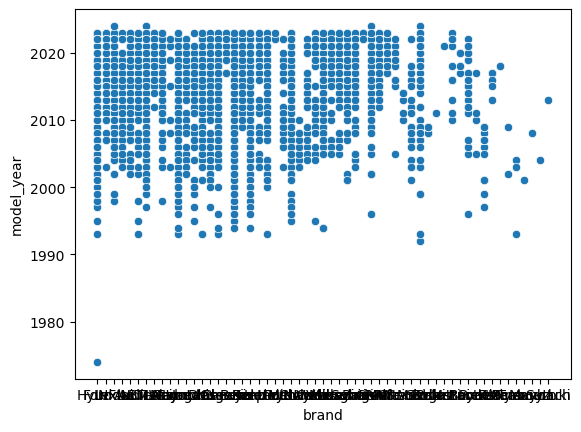

In [58]:
sns.scatterplot(x=df['brand'],y=df['model_year'])

C:\Users\abhin\AppData\Local\Temp\ipykernel_11460\1661515095.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['milage'])


<Axes: xlabel='milage', ylabel='Density'>

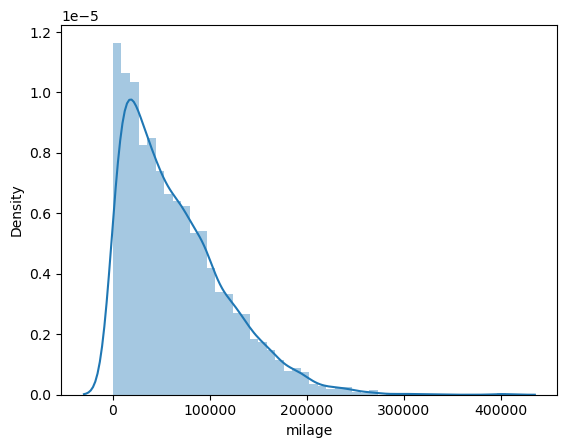

In [59]:
sns.distplot(df['milage'])

<Axes: xlabel='milage'>

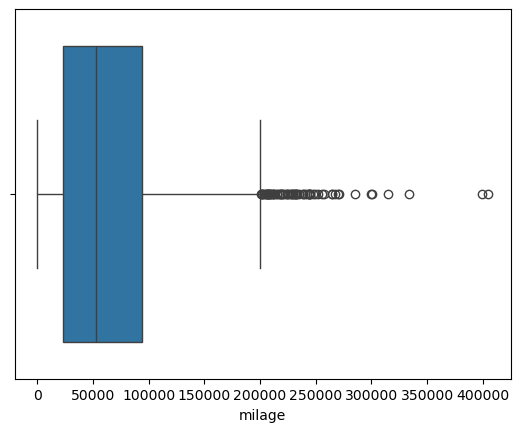

In [60]:
sns.boxplot(x=df['milage'])

<Axes: xlabel='fuel_type'>

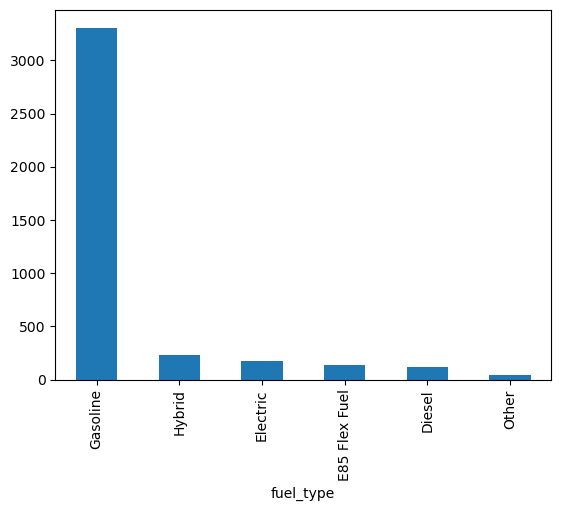

In [61]:
df['fuel_type'].value_counts().plot(kind='bar')

<Axes: xlabel='brand', ylabel='fuel_type'>

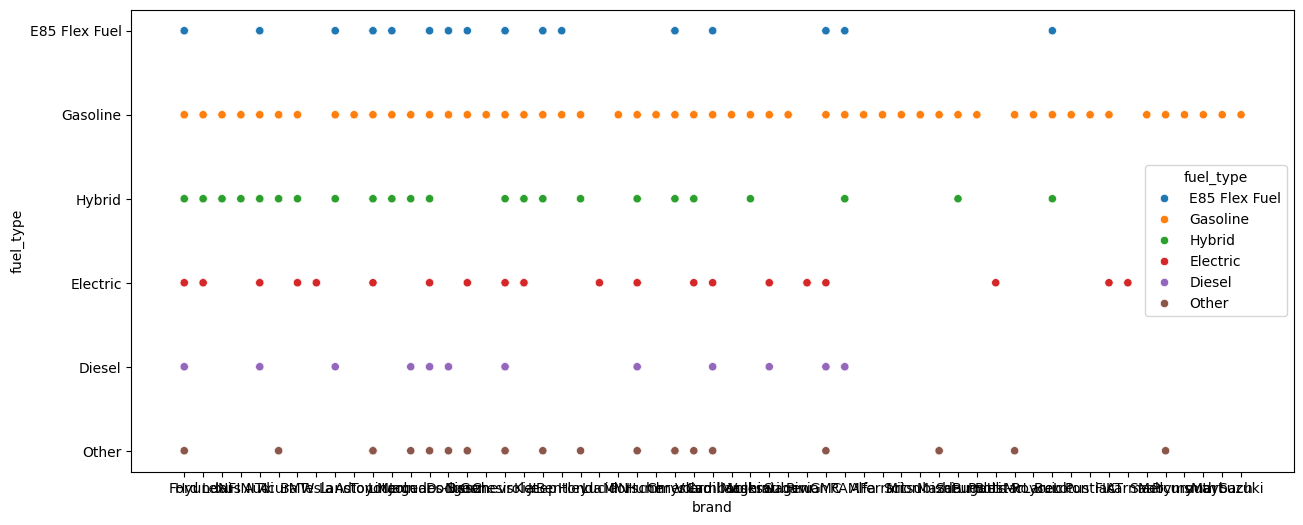

In [62]:
plt.figure(figsize=(15,6))
sns.scatterplot(x=df['brand'],y=df['fuel_type'],hue=df['fuel_type'])

<Axes: xlabel='accident'>

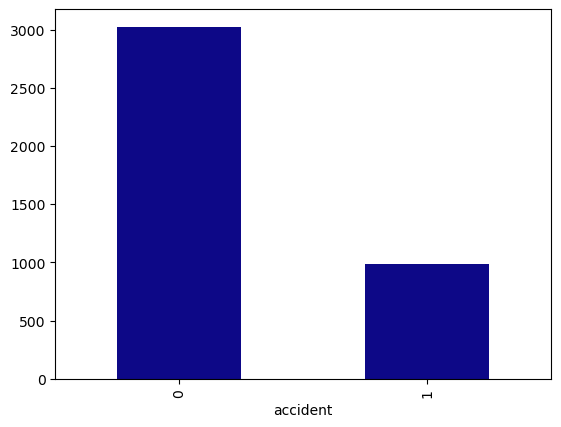

In [63]:
df['accident'].value_counts().plot(kind='bar',colormap='plasma')

<Axes: xlabel='clean_title'>

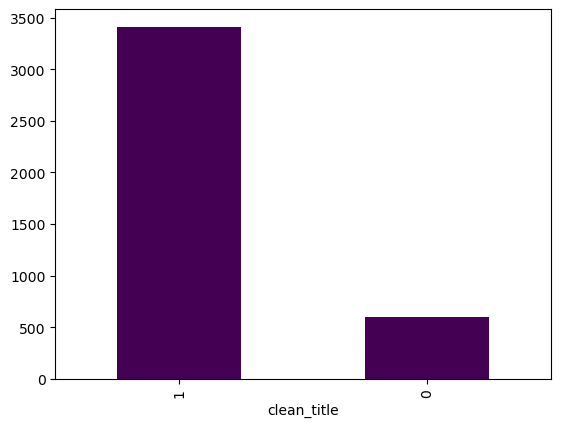

In [64]:
df['clean_title'].value_counts().plot(kind='bar',colormap='viridis')

C:\Users\abhin\AppData\Local\Temp\ipykernel_11460\444587821.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

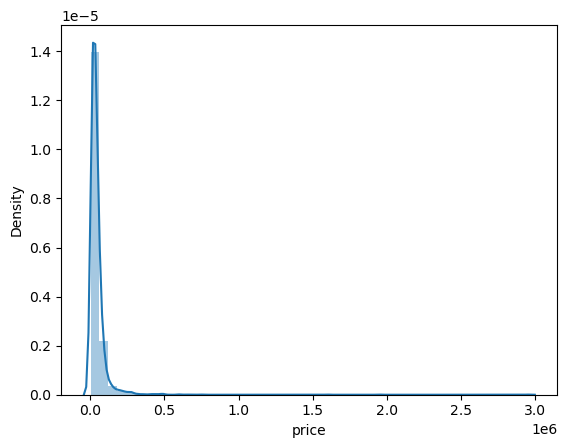

In [65]:
sns.distplot(df['price'])

<Axes: xlabel='price'>

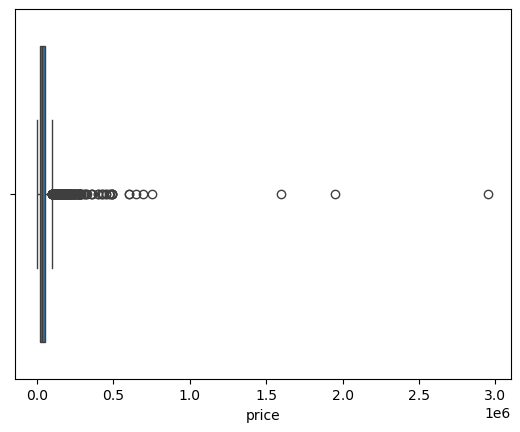

In [66]:
sns.boxplot(x=df['price'])

In [67]:
df['log_price']=np.log(df['price'])

C:\Users\abhin\AppData\Local\Temp\ipykernel_11460\3658590065.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['log_price'])


<Axes: xlabel='log_price', ylabel='Density'>

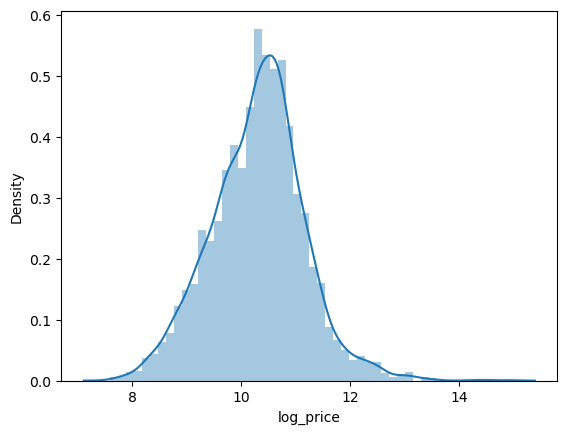

In [68]:
sns.distplot(df['log_price'])

<Axes: xlabel='log_price'>

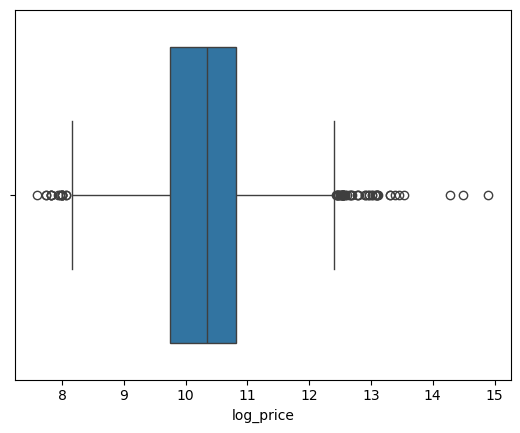

In [69]:
sns.boxplot(x=df['log_price'])

In [70]:
df['car_age']=2024 - df['model_year']

<Axes: xlabel='car_age'>

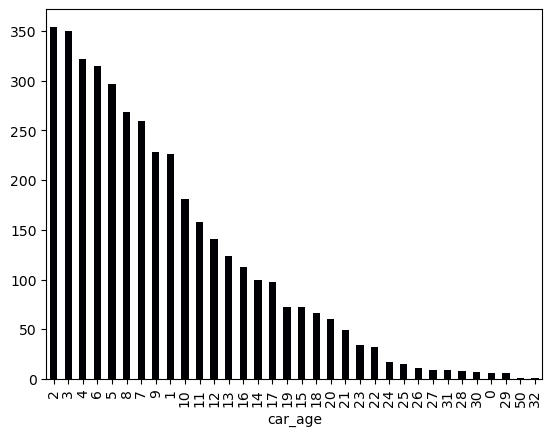

In [71]:
df['car_age'].value_counts().plot(kind='bar',colormap='inferno')

C:\Users\abhin\AppData\Local\Temp\ipykernel_11460\3777159862.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['engine_hp'],color='r')


<Axes: xlabel='engine_hp', ylabel='Density'>

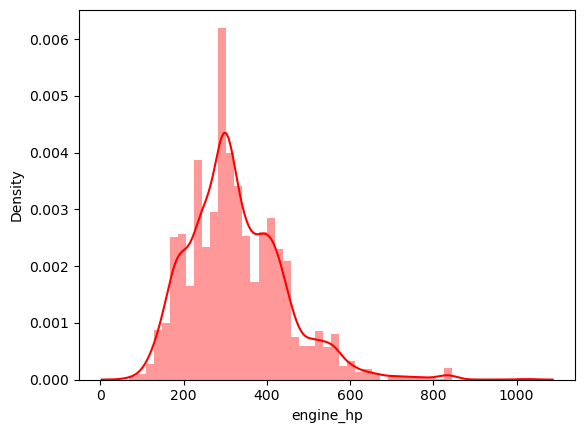

In [72]:
sns.distplot(df['engine_hp'],color='r')

<Axes: xlabel='engine_hp'>

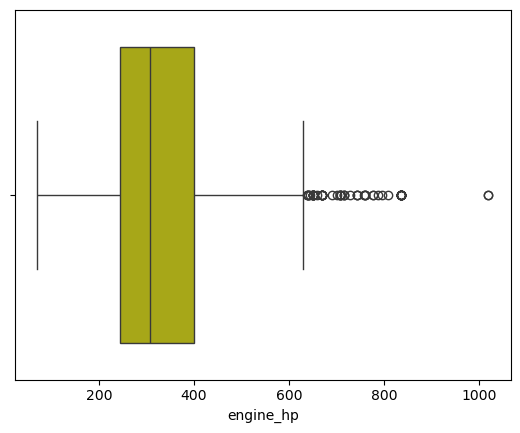

In [73]:
sns.boxplot(x=df['engine_hp'],color='y')

C:\Users\abhin\AppData\Local\Temp\ipykernel_11460\2528501144.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['liters'],color='b')


<Axes: xlabel='liters', ylabel='Density'>

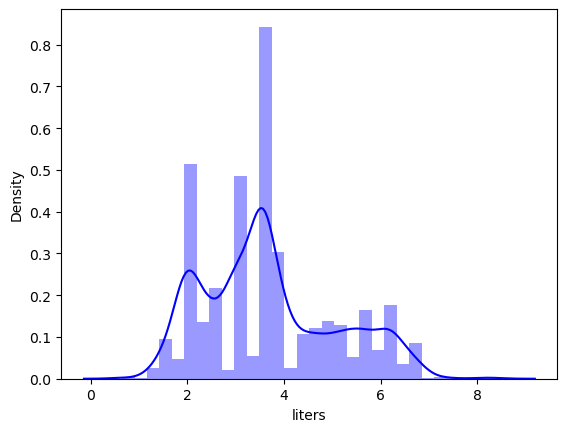

In [74]:
sns.distplot(df['liters'],color='b')

<Axes: xlabel='liters'>

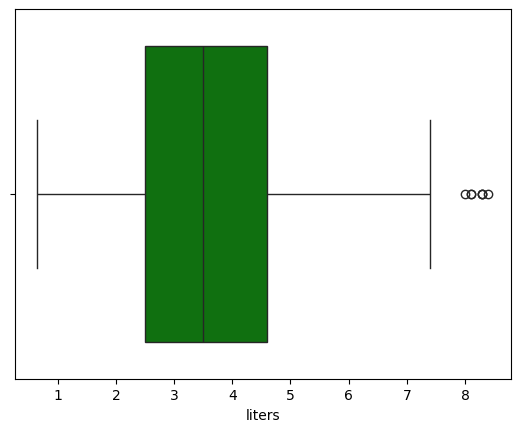

In [75]:
sns.boxplot(x=df['liters'],color='g')

<Axes: xlabel='v_engine'>

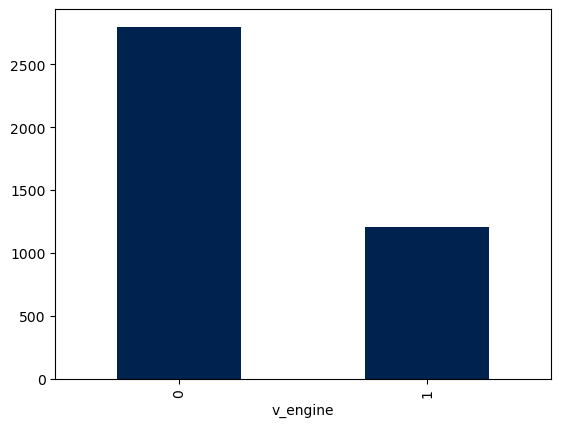

In [76]:
df['v_engine'].value_counts().plot(kind='bar',colormap='cividis')

<Axes: xlabel='transmission_type'>

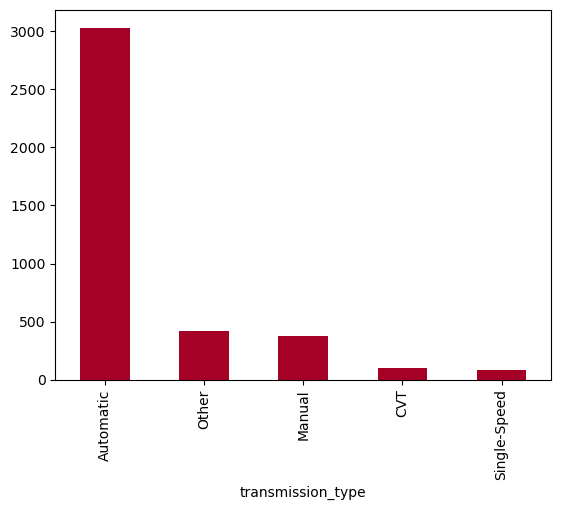

In [77]:
df['transmission_type'].value_counts().plot(kind='bar',colormap='RdYlBu')

In [78]:
df

,brand,model_year,milage,fuel_type,accident,clean_title,price,engine_hp,liters,v_engine,transmission_type,log_price,car_age
0,Ford,2013,51000,E85 Flex Fuel,1,1,10300,300.0,3.7,1,Automatic,9.239899,11
1,Hyundai,2021,34742,Gasoline,1,1,38005,344.0,3.8,1,Automatic,10.545473,3
2,Lexus,2022,22372,Gasoline,0,0,54598,295.0,3.5,0,Automatic,10.907753,2
3,INFINITI,2015,88900,Hybrid,0,1,15500,354.0,3.5,1,Automatic,9.648595,9
4,Audi,2021,9835,Gasoline,0,0,34999,240.0,2.0,0,Automatic,10.463075,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,2023,714,Gasoline,0,1,349950,390.0,6.0,0,Automatic,12.765546,1
4005,Audi,2022,10900,Gasoline,0,1,53900,349.0,3.0,1,Other,10.894886,2
4006,Porsche,2022,2116,Electric,0,0,90998,308.0,3.5,0,Automatic,11.418593,2
4007,Ford,2020,33000,Gasoline,0,1,62999,450.0,3.5,1,Automatic,11.050874,4


In [79]:
df['milage_per_year']=df.apply(lambda x : x['milage']/x['car_age'] if x['car_age']>0 else x['milage'],axis=1)

C:\Users\abhin\AppData\Local\Temp\ipykernel_11460\3213829050.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['milage_per_year'])


<Axes: xlabel='milage_per_year', ylabel='Density'>

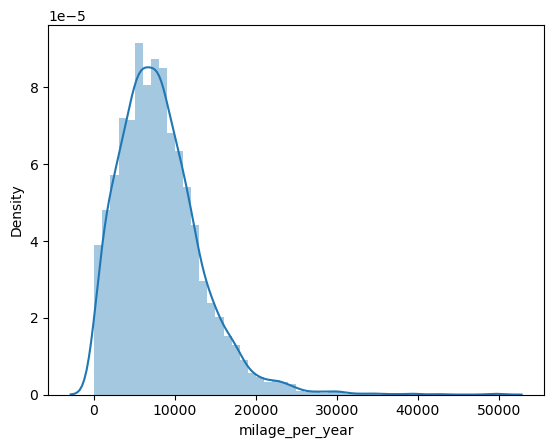

In [80]:
sns.distplot(df['milage_per_year'])

<Axes: xlabel='milage_per_year', ylabel='price'>

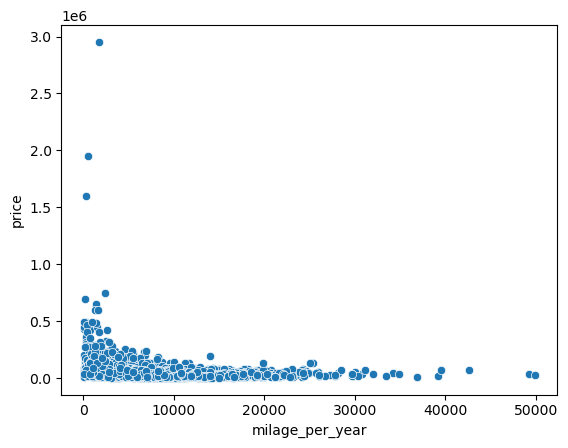

In [81]:
sns.scatterplot(x=df['milage_per_year'],y=df['price'])

<Axes: xlabel='milage_per_year', ylabel='log_price'>

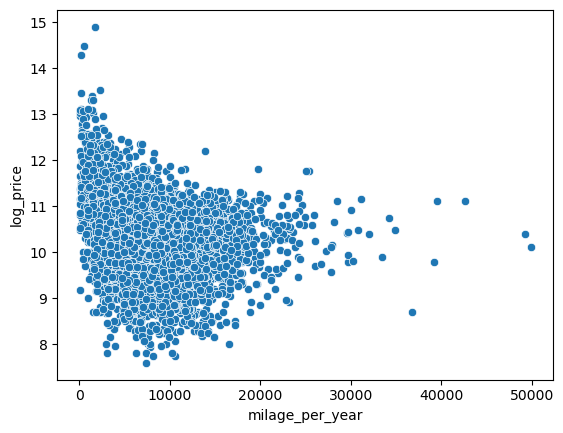

In [82]:
sns.scatterplot(x=df['milage_per_year'],y=df['log_price'])

<Axes: >

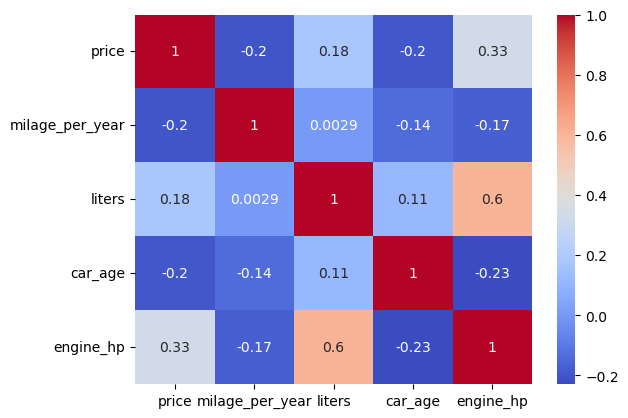

In [83]:
num_features=['price','milage_per_year','liters','car_age','engine_hp']
sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm')

In [84]:
columns=['engine_hp','price','milage','liters']

for col in columns:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr
    
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [85]:
df

,brand,model_year,milage,fuel_type,accident,clean_title,price,engine_hp,liters,v_engine,transmission_type,log_price,car_age,milage_per_year
0,Ford,2013,51000,E85 Flex Fuel,1,1,10300,300.0,3.7,1,Automatic,9.239899,11,4636.363636
1,Hyundai,2021,34742,Gasoline,1,1,38005,344.0,3.8,1,Automatic,10.545473,3,11580.666667
2,Lexus,2022,22372,Gasoline,0,0,54598,295.0,3.5,0,Automatic,10.907753,2,11186.000000
3,INFINITI,2015,88900,Hybrid,0,1,15500,354.0,3.5,1,Automatic,9.648595,9,9877.777778
4,Audi,2021,9835,Gasoline,0,0,34999,240.0,2.0,0,Automatic,10.463075,3,3278.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4003,Mercedes-Benz,2018,53705,Gasoline,1,1,25900,241.0,2.0,0,Automatic,10.161998,6,8950.833333
4005,Audi,2022,10900,Gasoline,0,1,53900,349.0,3.0,1,Other,10.894886,2,5450.000000
4006,Porsche,2022,2116,Electric,0,0,90998,308.0,3.5,0,Automatic,11.418593,2,1058.000000
4007,Ford,2020,33000,Gasoline,0,1,62999,450.0,3.5,1,Automatic,11.050874,4,8250.000000


In [86]:
df=df.drop(columns=['model_year'])

In [87]:
categorical_cols = [
    'brand','fuel_type','transmission_type'
]

In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5
))
])

In [90]:
x=df.drop(columns=['log_price','price'])
y=df['log_price']

In [91]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [92]:
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)

In [93]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(np.exp(y_test), np.exp(y_pred))

In [94]:
print(mae)

5872.517415948181


In [95]:
df['price'].mean()

32970.785438499726

Text(0, 0.5, 'Predicted')

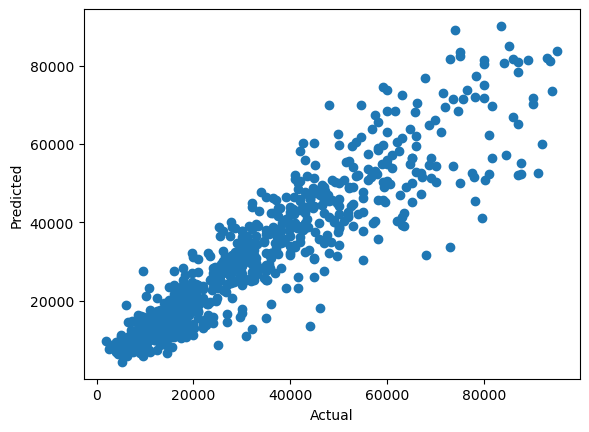

In [96]:
import matplotlib.pyplot as plt

plt.scatter(np.exp(y_test), np.exp(y_pred))
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [97]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8

))
])

In [98]:
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)

In [99]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(np.exp(y_test), np.exp(y_pred))
print(mae)

5132.972643471289


In [100]:
import joblib

joblib.dump(pipeline, 'car_price_model.joblib')
    
print("Model saved Successfully")

Model saved Successfully


In [101]:
df['fuel_type'].unique()

array(['E85 Flex Fuel', 'Gasoline', 'Hybrid', 'Electric', 'Diesel',
       'Other'], dtype=object)

In [102]:
df['transmission_type'].unique()

array(['Automatic', 'Other', 'Manual', 'CVT', 'Single-Speed'],
      dtype=object)

In [103]:
df

,brand,milage,fuel_type,accident,clean_title,price,engine_hp,liters,v_engine,transmission_type,log_price,car_age,milage_per_year
0,Ford,51000,E85 Flex Fuel,1,1,10300,300.0,3.7,1,Automatic,9.239899,11,4636.363636
1,Hyundai,34742,Gasoline,1,1,38005,344.0,3.8,1,Automatic,10.545473,3,11580.666667
2,Lexus,22372,Gasoline,0,0,54598,295.0,3.5,0,Automatic,10.907753,2,11186.000000
3,INFINITI,88900,Hybrid,0,1,15500,354.0,3.5,1,Automatic,9.648595,9,9877.777778
4,Audi,9835,Gasoline,0,0,34999,240.0,2.0,0,Automatic,10.463075,3,3278.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4003,Mercedes-Benz,53705,Gasoline,1,1,25900,241.0,2.0,0,Automatic,10.161998,6,8950.833333
4005,Audi,10900,Gasoline,0,1,53900,349.0,3.0,1,Other,10.894886,2,5450.000000
4006,Porsche,2116,Electric,0,0,90998,308.0,3.5,0,Automatic,11.418593,2,1058.000000
4007,Ford,33000,Gasoline,0,1,62999,450.0,3.5,1,Automatic,11.050874,4,8250.000000


In [108]:
df['milage_per_year'].describe()

count     3626.000000
mean      8434.768410
std       4890.729587
min         50.000000
25%       5045.437500
50%       7800.350000
75%      11000.000000
max      49278.000000
Name: milage_per_year, dtype: float64